In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [24]:
df = pd.read_csv(r'D:\sprints project\heart_disease.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


- **age**: age in years  

- **sex**: sex (1 = male; 0 = female)  

- **cp**: chest pain type  
  - Value 1: typical angina  
  - Value 2: atypical angina  
  - Value 3: non-anginal pain  
  - Value 4: asymptomatic  

- **trestbps**: resting blood pressure (in mm Hg on admission to the hospital)  

- **chol**: serum cholestoral in mg/dl  

- **fbs**: (fasting blood sugar > 120 mg/dl)  (1 = true; 0 = false)  

- **restecg**: resting electrocardiographic results  
  - Value 0: normal  
  - Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)  
  - Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria  

- **thalach**: maximum heart rate achieved  

- **exang**: exercise induced angina (1 = yes; 0 = no)  

- **oldpeak**: ST depression induced by exercise relative to rest  

- **slope**: the slope of the peak exercise ST segment  
  - Value 1: upsloping  
  - Value 2: flat  
  - Value 3: downsloping  

- **ca**: number of major vessels (0-3) colored by flourosopy  

- **thal**:  
  - 3 = normal  
  - 6 = fixed defect  
  - 7 = reversable defect  

- **num**: diagnosis of heart disease (angiographic disease status)  
  - Value 0: < 50% diameter narrowing  
  - Value 1: > 50% diameter narrowing  
    (in any major vessel: attributes 59 through 68 are vessels)  

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [26]:
df.duplicated().sum() / len(df)

np.float64(0.0)

In [27]:
df.isna().sum() / len(df)

age         0.000000
sex         0.000000
cp          0.000000
trestbps    0.000000
chol        0.000000
fbs         0.000000
restecg     0.000000
thalach     0.000000
exang       0.000000
oldpeak     0.000000
slope       0.000000
ca          0.013201
thal        0.006601
num         0.000000
dtype: float64

There is small ratio of nan values so we will easly drop them

In [28]:
df = df.dropna()

In [29]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.946128
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,1.234551
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [30]:
df['cp'].value_counts()

cp
4    142
3     83
2     49
1     23
Name: count, dtype: int64

In [31]:
df['restecg'].value_counts()

restecg
0    147
2    146
1      4
Name: count, dtype: int64

In [32]:
df['exang'].value_counts()

exang
0    200
1     97
Name: count, dtype: int64

In [33]:
df['slope'].value_counts()

slope
1    139
2    137
3     21
Name: count, dtype: int64

In [34]:
df['ca'].value_counts()

ca
0.0    174
1.0     65
2.0     38
3.0     20
Name: count, dtype: int64

In [35]:
df['thal'].value_counts()

thal
3.0    164
7.0    115
6.0     18
Name: count, dtype: int64

In [36]:
df['num'].value_counts()

num
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64

In [37]:
df["num"] = df["num"].apply(lambda x: 0 if x == 0 else 1)
# sex 
sex_map = {0: "Female", 1: "Male"}

# cp (Chest Pain Type)
cp_map = {
    1: "Typical Angina",
    2: "Atypical Angina",
    3: "Non-anginal Pain",
    4: "Asymptomatic"
}

# fbs (Fasting Blood Sugar)
fbs_map = {0: "≤ 120 mg/dl", 1: "> 120 mg/dl"}

# restecg (Resting ECG Results)
restecg_map = {
    0: "Normal",
    1: "ST-T Abnormality",
    2: "Left Ventricular Hypertrophy"
}

# exang (Exercise Induced Angina)
exang_map = {0: "No", 1: "Yes"}

# slope (Slope of Peak Exercise ST Segment)
slope_map = {
    1: "Upsloping",
    2: "Flat",
    3: "Downsloping"
}

# thal (Thallium Stress Test)
thal_map = {
    3: "Normal",
    6: "Fixed Defect",
    7: "Reversible Defect"
}

# num (Target - Heart Disease Diagnosis)
num_map = {
    0: "No Disease",
    1: "Have Disease",
}

labeled_df = df.copy()

In [38]:
labeled_df['sex_label'] = df['sex'].map(sex_map)
labeled_df['cp_label'] = df['cp'].map(cp_map)
labeled_df['fbs_label'] = df['fbs'].map(fbs_map)
labeled_df['restecg_label'] = df['restecg'].map(restecg_map)
labeled_df['exang_label'] = df['exang'].map(exang_map)
labeled_df['slope_label'] = df['slope'].map(slope_map)
labeled_df['thal_label'] = df['thal'].map(thal_map)
labeled_df['num_label'] = df['num'].map(num_map)

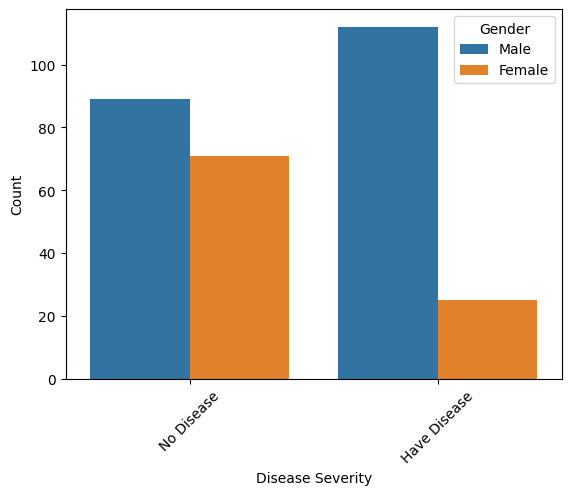

In [39]:
sns.countplot(data=labeled_df, x='num_label', hue='sex_label')
plt.xticks(rotation = 45)
plt.xlabel("Disease Severity")   
plt.ylabel("Count")              
plt.legend(title="Gender")
plt.show()

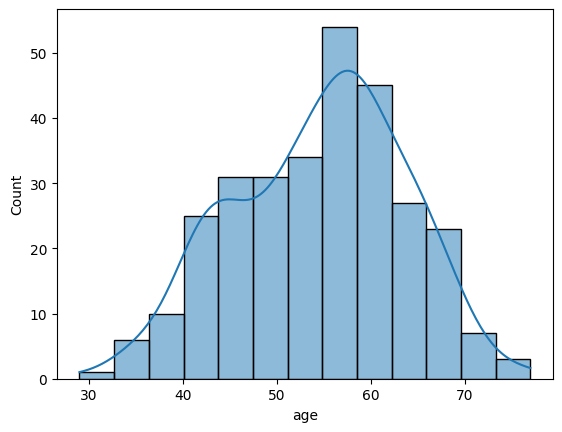

In [40]:
sns.histplot(data=labeled_df,x='age',kde=True)
plt.show()

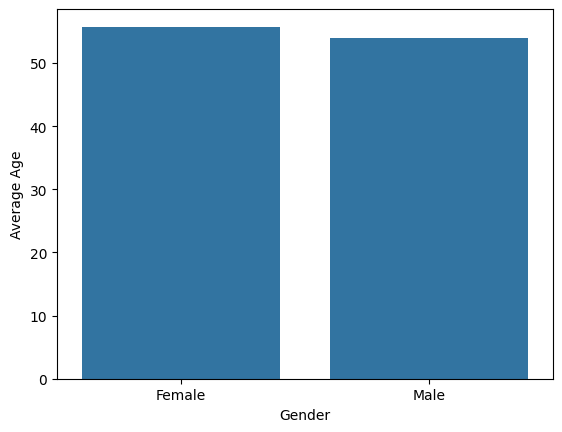

In [41]:
age_by_sex = labeled_df.groupby('sex_label')['age'].mean().reset_index()
sns.barplot(data=age_by_sex, x='sex_label', y='age')
plt.xlabel("Gender")
plt.ylabel("Average Age")
plt.show()

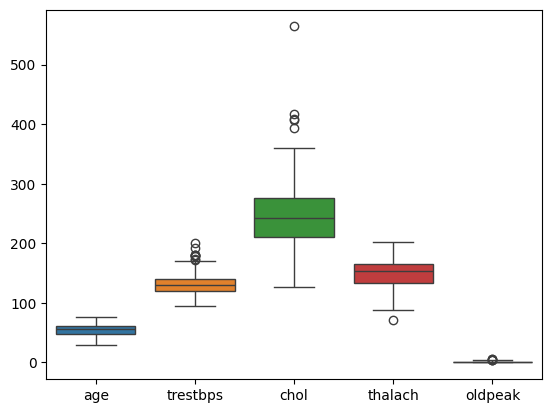

In [42]:
sns.boxplot(df[['age','trestbps','chol','thalach','oldpeak']])
plt.show()

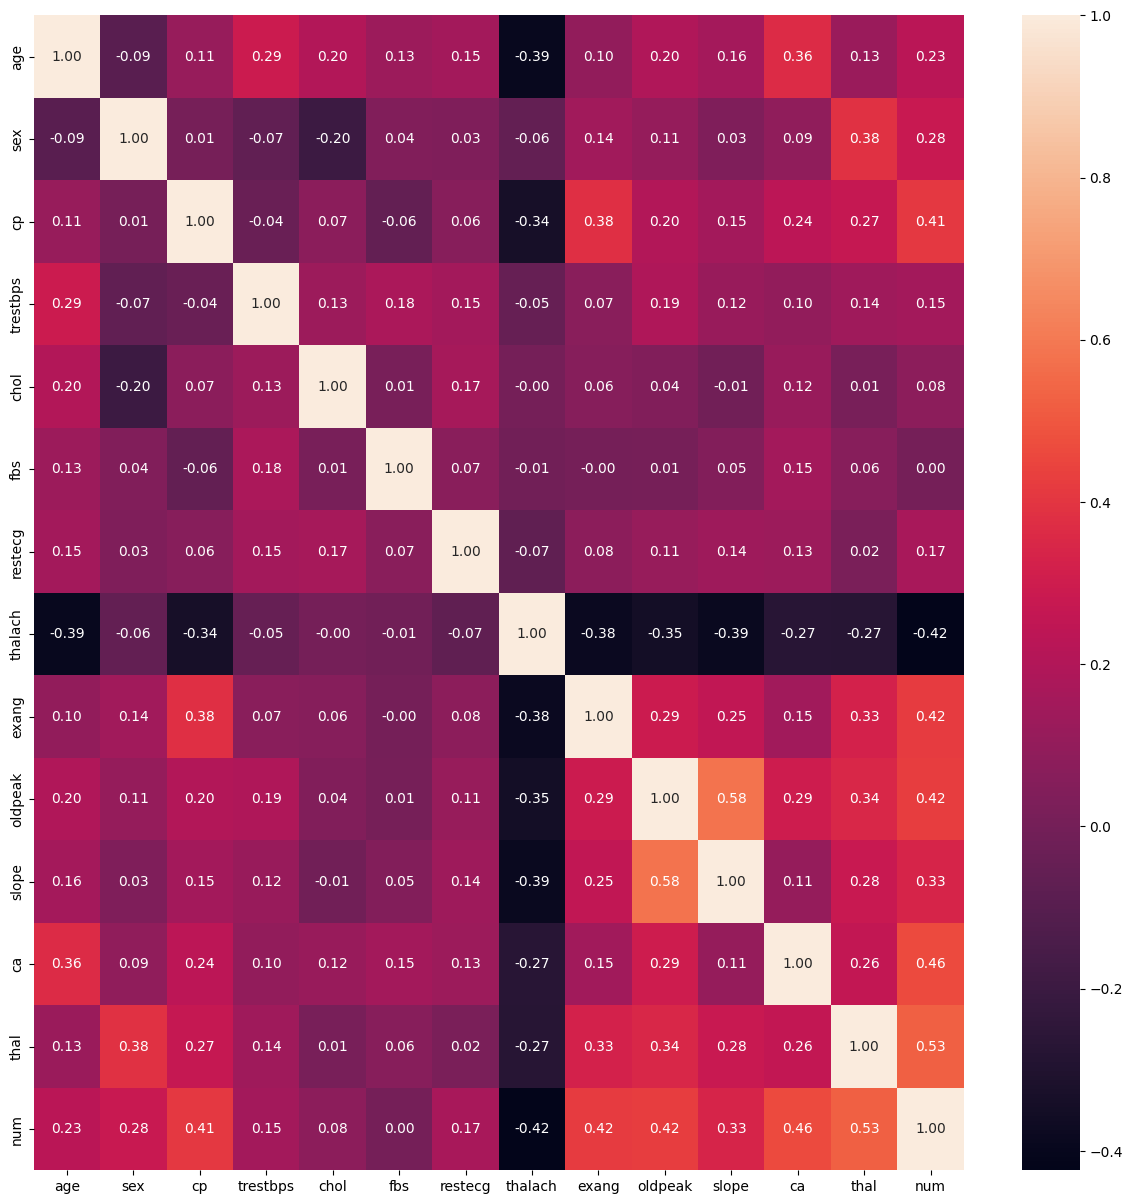

In [43]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(),fmt='.2f',annot=True)
plt.show()

In [44]:
df.to_csv("D:\sprints project\processed_data.csv", index=False)